In [1]:
import pandas as pd
df=pd.read_csv('purplle_campaign_data_with_nulls.csv')
df

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,PU-CMP-1000,Paid Ads,Working Women,6.0,"Facebook, Google",31869.0,3490.0,1946.0,902.0,493394.0,55.93,8.78,Tamil,19.89,Premium Shoppers,27-12-2024
1,PU-CMP-1001,Paid Ads,Premium Shoppers,8.0,"Instagram, WhatsApp",26640.0,2441.0,741.0,314.0,108644.0,197.44,0.75,Bengali,13.12,NaN,26-11-2024
2,PU-CMP-1002,Influencer,Youth,22.0,"Facebook, WhatsApp",36967.0,4997.0,1025.0,653.0,NaN,234.59,0.56,NaN,18.06,College Students,08-01-2025
3,PU-CMP-1003,Paid Ads,Youth,15.0,"Instagram, WhatsApp",73258.0,5893.0,2565.0,1970.0,1341570.0,103.76,5.56,Bengali,14.23,College Students,14-03-2025
4,PU-CMP-1004,Social Media,Premium Shoppers,11.0,"WhatsApp, Instagram",91081.0,6393.0,3282.0,2582.0,787510.0,78.61,NaN,English,13.46,College Students,11-07-2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55550,PU-CMP-56550,SEO,Premium Shoppers,10.0,"WhatsApp, Instagram",58191.0,7763.0,3471.0,2132.0,1097980.0,73.52,6.00,Tamil,22.97,Youth,08-05-2025
55551,PU-CMP-56551,Email,Tier 2 City Customers,12.0,"YouTube, Google",85085.0,8986.0,4096.0,2308.0,800876.0,53.17,5.53,Tamil,18.09,College Students,23-08-2024
55552,PU-CMP-56552,Email,College Students,29.0,"YouTube, Google, Email",66094.0,4051.0,2155.0,1307.0,414319.0,113.10,1.80,Bengali,NaN,NaN,09-11-2024
55553,PU-CMP-56553,Paid Ads,College Students,7.0,"Facebook, WhatsApp",65050.0,5196.0,2263.0,1235.0,737295.0,237.80,NaN,Hindi,13.37,Youth,30-09-2024


In [2]:
df=df.drop_duplicates()

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       52871 non-null  str    
 1   Campaign_Type     52765 non-null  str    
 2   Target_Audience   52808 non-null  str    
 3   Duration          52787 non-null  float64
 4   Channel_Used      52811 non-null  str    
 5   Impressions       52834 non-null  float64
 6   Clicks            52843 non-null  float64
 7   Leads             52901 non-null  float64
 8   Conversions       52881 non-null  float64
 9   Revenue           52792 non-null  float64
 10  Acquisition_Cost  52857 non-null  float64
 11  ROI               52824 non-null  float64
 12  Language          52810 non-null  str    
 13  Engagement_Score  52953 non-null  float64
 14  Customer_Segment  52879 non-null  str    
 15  Date              52904 non-null  str    
dtypes: float64(9), str(7)
memory usage: 10.9 MB


In [4]:
null_info = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(2),
    'dtype': df.dtypes
})

print(null_info[null_info['null_count'] > 0])

                  null_count  null_%    dtype
Campaign_ID             2684    4.83      str
Campaign_Type           2790    5.02      str
Target_Audience         2747    4.94      str
Duration                2768    4.98  float64
Channel_Used            2744    4.94      str
Impressions             2721    4.90  float64
Clicks                  2712    4.88  float64
Leads                   2654    4.78  float64
Conversions             2674    4.81  float64
Revenue                 2763    4.97  float64
Acquisition_Cost        2698    4.86  float64
ROI                     2731    4.92  float64
Language                2745    4.94      str
Engagement_Score        2602    4.68  float64
Customer_Segment        2676    4.82      str
Date                    2651    4.77      str


In [5]:
df=df.dropna(subset=["Campaign_ID"])

In [6]:
cat_cols = ['Campaign_Type', 'Target_Audience', 'Channel_Used', 'Language', 'Customer_Segment']

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

In [7]:
df['Engagement_Score']=df['Engagement_Score'].fillna(df['Engagement_Score'].mean())
df['Revenue']=df['Revenue'].fillna(df['Revenue'].median())

In [8]:
mask = df['ROI'].isnull() & df['Revenue'].notnull() & df['Acquisition_Cost'].notnull()
df.loc[mask, 'ROI'] = df.loc[mask, 'Revenue'] / df.loc[mask, 'Acquisition_Cost']
print("ROI nulls remaining:", df['ROI'].isnull().sum())
df['ROI'].fillna(df['ROI'].median())

ROI nulls remaining: 153


0            8.780000
1            0.750000
2            0.560000
3            5.560000
4        10017.936649
             ...     
55550        6.000000
55551        5.530000
55552        1.800000
55553     3100.483600
55554        1.010000
Name: ROI, Length: 52871, dtype: float64

In [9]:
df['Impressions'] = df.groupby('Channel_Used')['Impressions'] \
                      .transform(lambda x: x.fillna(x.median()))
df['Clicks'] = df.groupby('Channel_Used')['Clicks'] \
                 .transform(lambda x: x.fillna(x.median()))

In [10]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from sklearn.impute import KNNImputer

numeric_cols = ['Duration', 'Impressions', 'Clicks', 'Leads',
                'Conversions', 'Revenue', 'Acquisition_Cost', 'Engagement_Score']

imputer = KNNImputer(n_neighbors=5)

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [12]:
mask = df['ROI'].isnull() & df['Revenue'].notnull() & df['Acquisition_Cost'].notnull()
df.loc[mask, 'ROI'] = df.loc[mask, 'Revenue'] / df.loc[mask, 'Acquisition_Cost']
print("ROI nulls remaining:", df['ROI'].isnull().sum())
df['ROI'].fillna(df['ROI'].median())

ROI nulls remaining: 0


0            8.780000
1            0.750000
2            0.560000
3            5.560000
4        10017.936649
             ...     
55550        6.000000
55551        5.530000
55552        1.800000
55553     3100.483600
55554        1.010000
Name: ROI, Length: 52871, dtype: float64

In [13]:
df= df.drop('Date',axis=1)

In [14]:
# 1. Basic structure check
df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment
0,PU-CMP-1000,Paid Ads,Working Women,6.0,"Facebook, Google",31869.0,3490.0,1946.0,902.0,493394.0,55.93,8.780000,Tamil,19.89,Premium Shoppers
1,PU-CMP-1001,Paid Ads,Premium Shoppers,8.0,"Instagram, WhatsApp",26640.0,2441.0,741.0,314.0,108644.0,197.44,0.750000,Bengali,13.12,Unknown
2,PU-CMP-1002,Influencer,Youth,22.0,"Facebook, WhatsApp",36967.0,4997.0,1025.0,653.0,358192.0,234.59,0.560000,Unknown,18.06,College Students
3,PU-CMP-1003,Paid Ads,Youth,15.0,"Instagram, WhatsApp",73258.0,5893.0,2565.0,1970.0,1341570.0,103.76,5.560000,Bengali,14.23,College Students
4,PU-CMP-1004,Social Media,Premium Shoppers,11.0,"WhatsApp, Instagram",91081.0,6393.0,3282.0,2582.0,787510.0,78.61,10017.936649,English,13.46,College Students


In [15]:
# 2. Summary statistics
df.describe()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,52871.000000,52871.000000,52871.000000,52871.000000,52871.000000,5.287100e+04,52871.000000,52871.000000,52871.000000
mean,17.484489,55075.262772,4645.380407,1869.857722,1028.303153,5.060859e+05,376.836161,315.707246,13.759624
std,7.341332,25332.510348,3108.227058,1425.008452,854.826228,4.767377e+05,530.819750,3663.779809,6.186084
min,5.000000,10002.000000,207.000000,48.000000,19.000000,6.061000e+03,9.340000,-0.970000,2.560000
25%,11.000000,33778.000000,2184.000000,783.000000,401.000000,1.849150e+05,108.209000,0.090000,8.600000
50%,17.200000,55113.000000,3901.500000,1474.000000,776.000000,3.581920e+05,210.650000,1.390000,13.759624
75%,24.000000,76568.000000,6514.000000,2592.000000,1402.000000,6.614665e+05,431.790000,4.230000,18.530000
max,30.000000,100000.000000,14864.000000,8613.000000,6221.000000,4.345920e+06,12109.050000,312038.972163,30.990000


In [16]:
# 3. Shape and dtypes after cleaning
print(df.shape)
print(df.dtypes)

(52871, 15)
Campaign_ID             str
Campaign_Type           str
Target_Audience         str
Duration            float64
Channel_Used            str
Impressions         float64
Clicks              float64
Leads               float64
Conversions         float64
Revenue             float64
Acquisition_Cost    float64
ROI                 float64
Language                str
Engagement_Score    float64
Customer_Segment        str
dtype: object


In [17]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


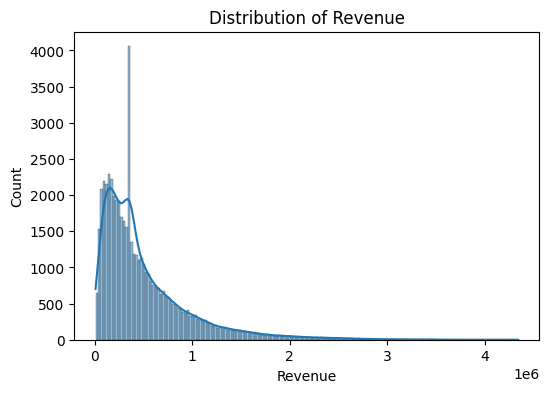

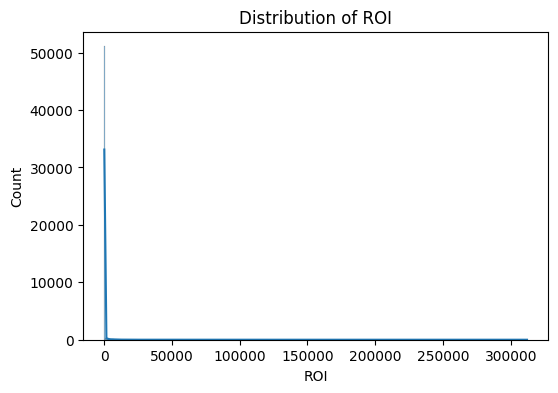

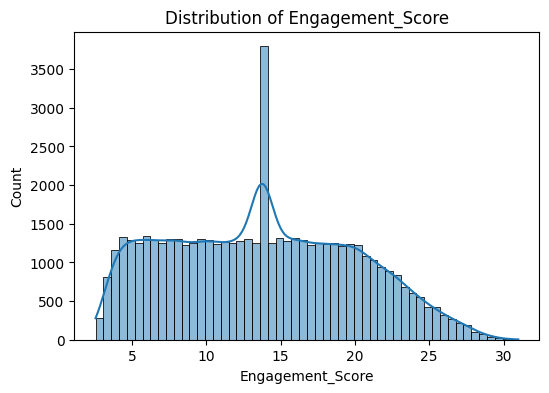

In [18]:
# 4. Univariate distribution - numeric columns
import matplotlib.pyplot as plt
import seaborn as sns

for col in ['Revenue', 'ROI', 'Engagement_Score']:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [19]:
# 5. Value counts for categorical columns
for col in ['Campaign_Type', 'Channel_Used', 'Customer_Segment', 'Target_Audience', 'Language']:
    print(df[col].value_counts())
    print()

Campaign_Type
Influencer      10207
Email           10176
Social Media     9957
SEO              9956
Paid Ads         9918
Unknown          2657
Name: count, dtype: int64

Channel_Used
Email                           2912
Facebook                        2836
Google                          2830
WhatsApp                        2755
YouTube                         2749
                                ... 
Email, Instagram, YouTube        119
Email, Google, YouTube           118
WhatsApp, Instagram, YouTube     115
Instagram, Google, Email         115
Instagram, Facebook, YouTube     114
Name: count, Length: 157, dtype: int64

Customer_Segment
Youth                    10251
Working Women            10064
College Students         10050
Tier 2 City Customers    10015
Premium Shoppers          9963
Unknown                   2528
Name: count, dtype: int64

Target_Audience
Youth                    10189
Premium Shoppers         10059
Working Women            10052
Tier 2 City Customers     99

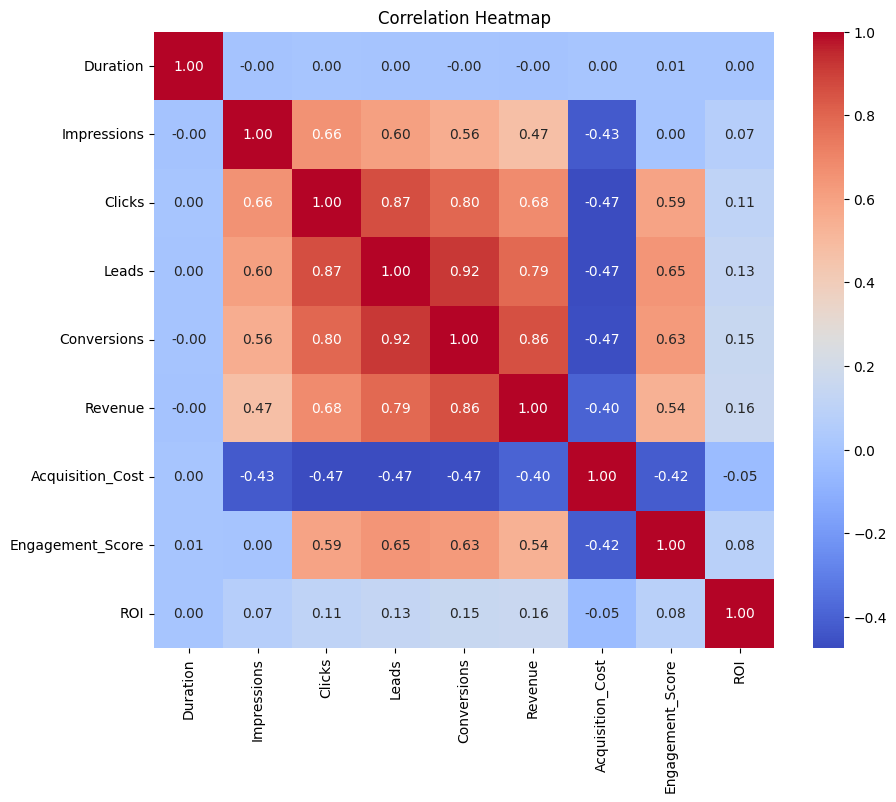

In [20]:
# 6. Correlation heatmap
numeric_cols = ['Duration', 'Impressions', 'Clicks', 'Leads',
                'Conversions', 'Revenue', 'Acquisition_Cost', 'Engagement_Score', 'ROI']

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

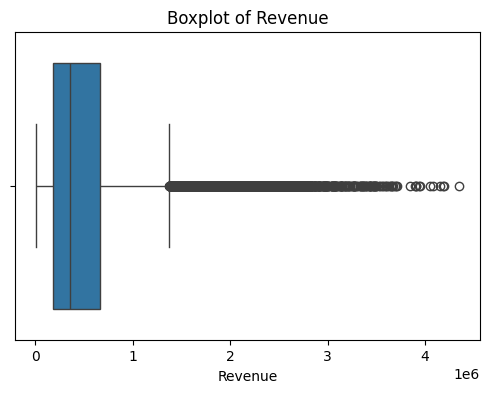

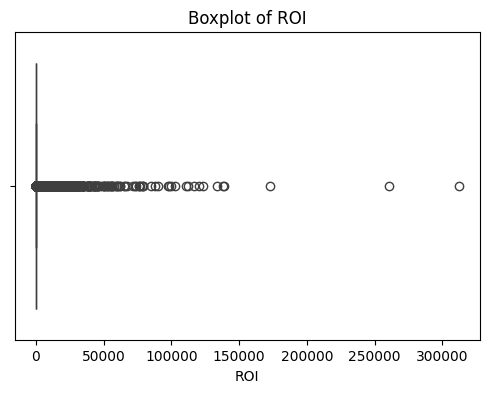

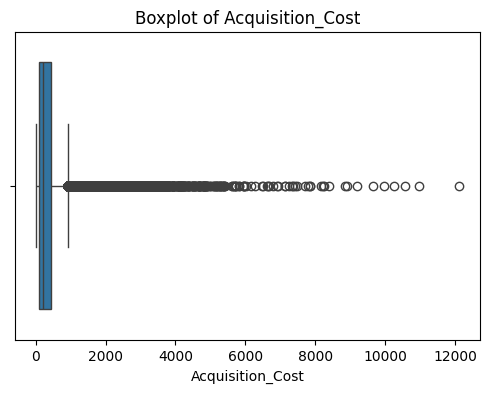

In [21]:
# 7. Boxplots for outlier detection
for col in ['Revenue', 'ROI', 'Acquisition_Cost']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [22]:
# 8. Groupby aggregations - performance by channel/segment
print(df.groupby('Channel_Used')['Revenue'].mean().sort_values(ascending=False))
print()
print(df.groupby('Campaign_Type')['ROI'].mean().sort_values(ascending=False))
print()
print(df.groupby('Customer_Segment')['Conversions'].sum().sort_values(ascending=False))

Channel_Used
WhatsApp, Email, Google          600810.676692
WhatsApp, Google, YouTube        593366.380952
Facebook, WhatsApp, Email        586460.645390
YouTube, Instagram, Google       584436.488550
Instagram, Facebook, WhatsApp    581749.929688
                                     ...      
Google, YouTube, WhatsApp        438639.120000
YouTube, Email, WhatsApp         437249.750000
Facebook, Google, WhatsApp       432811.563758
Facebook, Instagram, WhatsApp    412502.819444
Facebook, Email, Google          410121.546763
Name: Revenue, Length: 157, dtype: float64

Campaign_Type
Social Media    397.943391
Email           348.740621
SEO             317.454546
Unknown         298.204009
Paid Ads        293.631286
Influencer      226.855130
Name: ROI, dtype: float64

Customer_Segment
Youth                    10510958.8
College Students         10433445.4
Working Women            10331451.6
Tier 2 City Customers    10294447.8
Premium Shoppers         10222046.4
Unknown                   

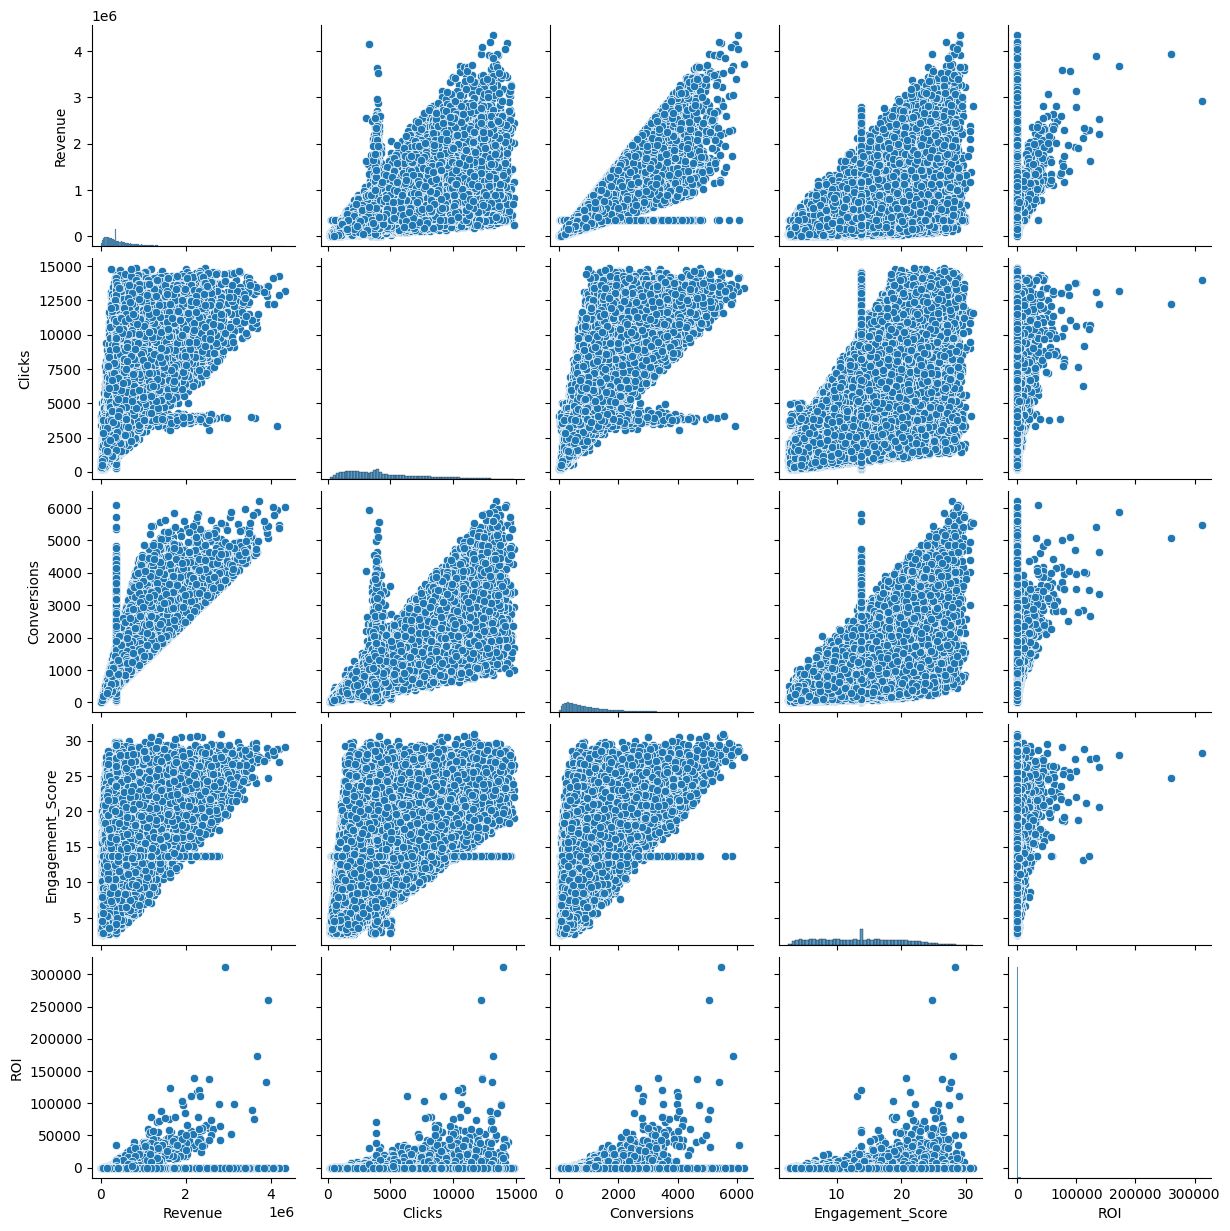

In [23]:
# 1. Pairplot - relationships between key numeric variables
sns.pairplot(df[['Revenue', 'Clicks', 'Conversions', 'Engagement_Score', 'ROI']])
plt.show()

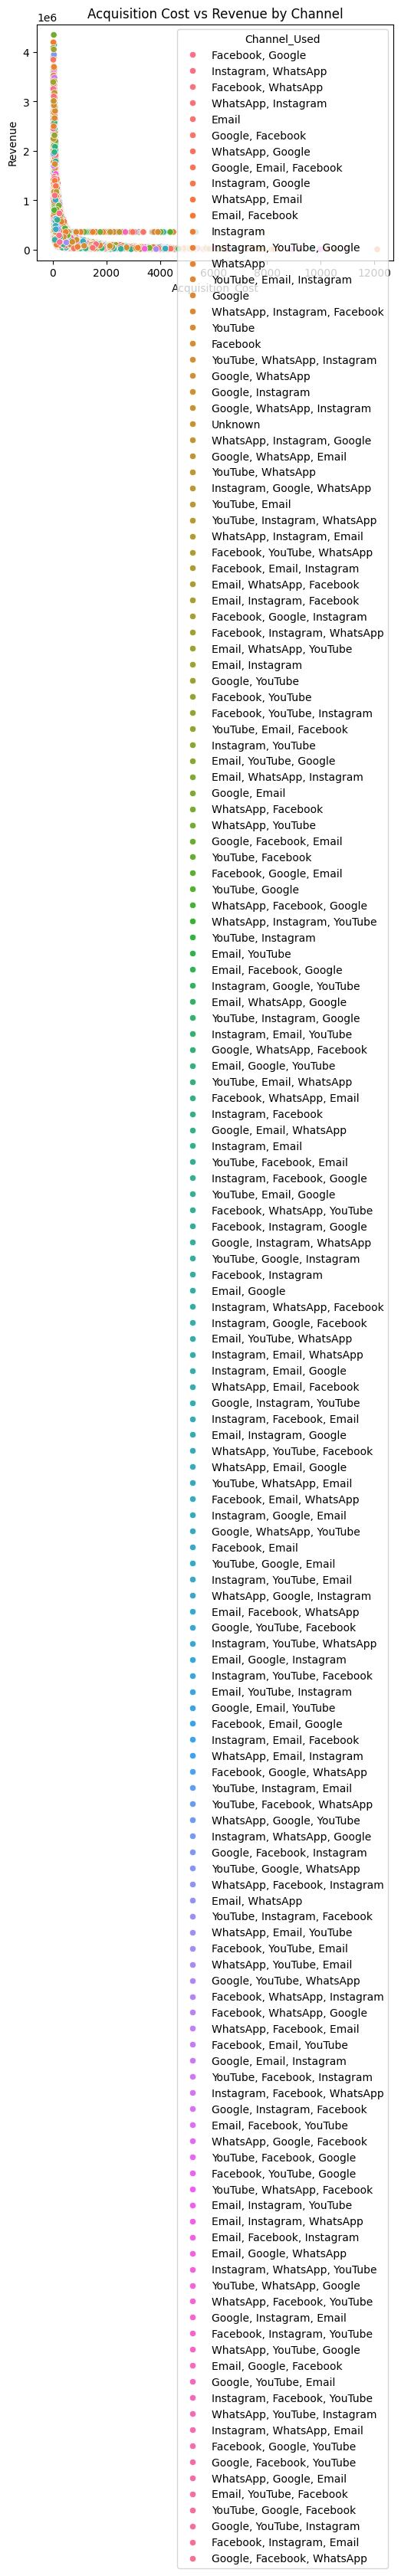

In [24]:
# 2. Scatter plot - Acquisition Cost vs Revenue
plt.figure(figsize=(6,4))
sns.scatterplot(x='Acquisition_Cost', y='Revenue', data=df, hue='Channel_Used')
plt.title('Acquisition Cost vs Revenue by Channel')
plt.show()

In [25]:
# 3. Skewness check for numeric columns
print(df[numeric_cols].skew())

Duration             0.003226
Impressions         -0.003038
Clicks               0.875444
Leads                1.251407
Conversions          1.569594
Revenue              2.137762
Acquisition_Cost     5.326748
Engagement_Score     0.171378
ROI                 33.841334
dtype: float64


In [26]:
# 4. Top/bottom performing campaigns
print("Top 5 by Revenue:")
print(df.nlargest(5, 'Revenue')[['Campaign_ID', 'Channel_Used', 'Revenue', 'ROI']])

print("\nBottom 5 by Revenue:")
print(df.nsmallest(5, 'Revenue')[['Campaign_ID', 'Channel_Used', 'Revenue', 'ROI']])

Top 5 by Revenue:
        Campaign_ID                Channel_Used    Revenue    ROI
21268  PU-CMP-22268           WhatsApp, YouTube  4345920.0  20.53
35294  PU-CMP-36294                   Instagram  4195620.0  37.33
8438    PU-CMP-9438    Instagram, Email, Google  4184550.0  23.24
8523    PU-CMP-9523  YouTube, Google, Instagram  4148565.0  13.38
47391  PU-CMP-48391           Facebook, YouTube  4082655.0  55.72

Bottom 5 by Revenue:
        Campaign_ID              Channel_Used  Revenue   ROI
16910  PU-CMP-17910  Email, WhatsApp, YouTube   6061.0 -0.95
14953  PU-CMP-15953  YouTube, Facebook, Email   6902.0 -0.88
23764  PU-CMP-24764                   Unknown   7350.0 -0.97
29673  PU-CMP-30673          Facebook, Google   7455.0 -0.95
31028  PU-CMP-32028                     Email   9072.0 -0.97


In [28]:
# 5. Cross-tabulation - Campaign_Type vs Channel_Used
pd.crosstab(df['Campaign_Type'], df['Channel_Used'])

Channel_Used,Email,"Email, Facebook","Email, Facebook, Google","Email, Facebook, Instagram","Email, Facebook, WhatsApp","Email, Facebook, YouTube","Email, Google","Email, Google, Facebook","Email, Google, Instagram","Email, Google, WhatsApp",...,"YouTube, Instagram","YouTube, Instagram, Email","YouTube, Instagram, Facebook","YouTube, Instagram, Google","YouTube, Instagram, WhatsApp","YouTube, WhatsApp","YouTube, WhatsApp, Email","YouTube, WhatsApp, Facebook","YouTube, WhatsApp, Google","YouTube, WhatsApp, Instagram"
Campaign_Type,,,,,,,,,,,,,,,,,,,,,
Email,548,128,25,23,23,28,98,31,29,19,...,113,35,30,16,26,132,25,31,28,32
Influencer,571,88,17,27,29,26,101,36,32,27,...,103,30,33,24,36,108,29,22,25,32
Paid Ads,588,122,35,21,26,18,115,28,29,24,...,105,37,24,25,32,101,23,30,29,26
SEO,553,109,27,24,23,36,97,22,27,21,...,104,31,37,31,35,103,26,30,18,22
Social Media,512,103,31,25,19,24,114,35,28,32,...,95,25,30,27,20,108,29,35,25,17
Unknown,140,30,9,6,7,4,23,10,11,5,...,16,7,11,8,10,24,3,10,6,4


count    52871.000000
mean         0.221558
std          0.098113
min          0.004643
25%          0.151403
50%          0.205194
75%          0.278646
max          1.781212
Name: Conversion_Rate, dtype: float64


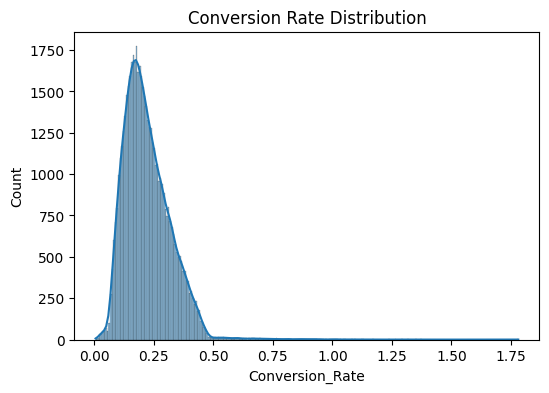

In [29]:
# 6. Conversion rate calculation (derived metric)
df['Conversion_Rate'] = df['Conversions'] / df['Clicks']
print(df['Conversion_Rate'].describe())

plt.figure(figsize=(6,4))
sns.histplot(df['Conversion_Rate'], kde=True)
plt.title('Conversion Rate Distribution')
plt.show()

In [49]:
# 7. Average metrics by Target Audience
df.groupby('Target_Audience')[['Revenue', 'ROI', 'Engagement_Score']].mean().sort_values('Revenue', ascending=False)

,Revenue,ROI,Engagement_Score
Target_Audience,,,
Youth,508807.497301,284.941809,13.805511
Tier 2 City Customers,508178.540678,366.977143,13.804061
Unknown,506326.442029,241.059175,13.760887
Working Women,505881.333267,279.513623,13.688118
College Students,505059.514665,330.329075,13.797892
Premium Shoppers,502408.043841,337.091040,13.702247


In [31]:
# 8. Check for any remaining anomalies after imputation
print("Remaining nulls:")
print(df.isnull().sum().sum())

print("\nNegative values check (shouldn't exist):")
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"{col}: {neg_count} negative values")

Remaining nulls:
0

Negative values check (shouldn't exist):
ROI: 12020 negative values


In [32]:
df.to_csv('purplle_cleaned.csv', index=False)